<p style="text-align:center"> 
    <a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/" target="_blank"> 
    <img src="../assets/logo.png" width="200" alt="Flavio Aguirre Logo"> 
    </a>
</p>

<h1 align="center"><font size="7"><strong>📉 ByeBye Predictor</strong></font></h1>
<br>
<hr>

## Reddit Comments – NLP Exploration & Design

**Date:** November 29, 2025  
**Subject:** Textual Signals from Reddit Comments – Telco Customer Experience

In the previous notebooks, we built and refined a **churn prediction pipeline** for the Telco Customer Churn dataset.  
We engineered domain-informed features and selected a **Logistic Regression model** as a strong, interpretable candidate for production.

However, real-world telco environments do not only generate **structured data** (contracts, payments, tenure).  
They also produce large amounts of **unstructured feedback**, such as:

- Support tickets
- Call center transcripts
- Social media and community comments (e.g. Reddit)

In this notebook, we focus on a small but realistic sample of **Reddit comments about telco services** (Movistar, Personal, Tuenti, etc.), and we aim to:

- Clean and explore the raw comments dataset stored in `data/raw/`.
- Define **business-relevant text labels**, such as:
  - `churn_signal`: whether the comment explicitly mentions leaving or switching provider.
- Design a **simple, production-oriented NLP pipeline** leveraging the existing `TextCleaner` transformer from `src/preprocess.py`.
- Prepare the ground to integrate text-based churn signals into the Telco churn pipeline in the next notebook.

---

### Expected Final Result of Notebook 06

This notebook is designed as a **bridge** between unstructured text data and our Telco churn modeling work.  
By the end of this notebook, we will have:

1. A **cleaned and inspected** version of the Reddit comments dataset, ready for modeling.
2. A clearly defined **churn-intent label** (`churn_signal`) derived from business-friendly rules applied to the comment text.
3. A first **EDA of the text**:
   - Distribution of comment scores.
   - Most frequent tokens after basic cleaning.
   - Examples of churn-intent vs non-churn comments.
4. A **designed NLP feature pipeline** (not fully trained yet) based on:
   - `TextCleaner` → text normalization and basic cleaning.
   - `TfidfVectorizer` → bag-of-words representation (unigrams + bigrams).
   - Optional `TruncatedSVD` → low-dimensional dense representation.
5. A documented plan for how this text pipeline will be used in the next notebook to:
   - Estimate a **text-based churn risk score** (`nlp_churn_score`).
   - Integrate that score into the broader Telco churn modeling pipeline.

The outcome of this notebook is not to maximize NLP performance, but to design a **clean, extensible and production-friendly** approach that can be scaled once more data and investment are available.

In [1]:
### Imports and setup
# NOTE: This notebook is intended to be run from the project root using Jupyter.

from notebooks_setup import PROJECT_ROOT

# -------- Local imports
from src.utils import get_logger
from src.data_loader import load_csv, preview_df, save_df
from src.eda import plot_numerical_distributions, plot_top_frequencies, config as eda_config
from src.preprocess import TextCleaner

# -------- External imports
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

%matplotlib inline

# Logger
logger = get_logger(__name__)

2025-11-29 21:13:14,030 | utils | INFO | Added project root to sys.path: C:\Users\Pc\Desktop\github
2025-11-29 21:13:15,807 | src.preprocess | INFO | NLTK resource 'punkt' is already downloaded.
2025-11-29 21:13:15,810 | src.preprocess | INFO | NLTK resource 'stopwords' is already downloaded.
2025-11-29 21:13:15,813 | src.preprocess | WARNING | NLTK resource 'wordnet' not found. Downloading...
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2025-11-29 21:13:15,917 | src.preprocess | INFO | NLTK resource 'punkt_tab' is already downloaded.
2025-11-29 21:13:15,918 | src.preprocess | INFO | Preprocess module loaded correctly and ready to be used.


In [2]:
# EDA configuration
eda_config.out_dir = "reports/figures/reddit-comments-nlp"
eda_config.apply()

In [3]:
### Initial configuration and dataset loading

# Paths to the raw Reddit comments and metadata
path_comments = "data/raw/public_comments.csv"
path_metadata = "data/raw/metadata_public_comments.md"  # if you want to load or just reference it

# Load the raw comments DataFrame
comments_df = load_csv(path_comments)

logger.info(f"Raw Reddit comments shape: {comments_df.shape}")
preview_df(comments_df)

2025-11-29 21:13:15,968 | src.data_loader | INFO | Loaded CSV: data/raw/public_comments.csv | Shape: (44, 7)
2025-11-29 21:13:15,971 | src.data_loader | INFO | Completed: load_csv
2025-11-29 21:13:15,973 | __main__ | INFO | Raw Reddit comments shape: (44, 7)


,comment_id,body,author,created_utc,score,parent_id,is_submitter
0,m8yc3ia,"No es que son 5000, son 5000 por cada persona ...",International_Luck60,1.737743e+09,116,t3_1i924b2,False
1,m8yjtrr,"Lo hacen de toda la vida. Antes eran los ""SMS ...",Happy_Scrotum,1.737745e+09,49,t3_1i924b2,False
2,m8zffac,por eso mismo me fui de personal en su momento...,usergghs,1.737754e+09,18,t3_1i924b2,False
3,m901q6d,"Telefono pre pago, desde el Nokia 1100 hasta d...",Belkan2087,1.737761e+09,9,t3_1i924b2,False
4,m90pvr2,36 LUCAS POR 6GB!!!! KJJJ \r\nLiteralmente por...,Storpa2,1.737769e+09,8,t3_1i924b2,False


In [4]:
## Basic Cleaning of Reddit Comments

"""
We start by performing minimal but essential cleaning steps:

1. Drop completely empty rows.
2. Remove any duplicated header row (if present in the CSV).
3. Ensure the core columns of interest (`comment_id`, `body`, `score`) are present.
"""

# 1) Drop completely empty rows
comments_df = comments_df.dropna(how="all").reset_index(drop=True)

# 2) Remove potential duplicated header rows (if the CSV contains headers repeated inside the data)
if "comment_id" in comments_df.columns:
    duplicated_header_mask = comments_df["comment_id"] == "comment_id"
    if duplicated_header_mask.any():
        logger.info("Duplicated header row detected in comments_df. Dropping it.")
        comments_df = comments_df[~duplicated_header_mask].reset_index(drop=True)

# 3) Sanity check for required columns
required_cols = ["comment_id", "body"]
missing_required = [c for c in required_cols if c not in comments_df.columns]
if missing_required:
    raise ValueError(f"Required columns missing in comments_df: {missing_required}")

logger.info(f"Cleaned Reddit comments shape: {comments_df.shape}")
preview_df(comments_df[["comment_id", "body"]].head(10))

2025-11-29 21:13:16,010 | __main__ | INFO | Cleaned Reddit comments shape: (44, 7)


,comment_id,body
0,m8yc3ia,"No es que son 5000, son 5000 por cada persona ..."
1,m8yjtrr,"Lo hacen de toda la vida. Antes eran los ""SMS ..."
2,m8zffac,por eso mismo me fui de personal en su momento...
3,m901q6d,"Telefono pre pago, desde el Nokia 1100 hasta d..."
4,m90pvr2,36 LUCAS POR 6GB!!!! KJJJ \r\nLiteralmente por...


### Heuristic churn-intent label

In [5]:
## Defining a churn-intent label from text

"""
In order to transform free-text comments into business signals, 
we introduce a simple binary label:

- `churn_signal = 1`: the comment clearly mentions leaving or switching provider.
- `churn_signal = 0`: otherwise.

For this first iteration, we rely on handcrafted patterns in Spanish that capture:
- "me fui de X", "me cambié a Y", "dar de baja", etc.

This is intentionally simple and transparent. 
It can be reviewed and refined by domain experts in future iterations.
"""

def detect_churn_signal(text: str) -> int:
    """
    Heuristic churn-intent detector based on simple Spanish patterns.
    Returns 1 if the comment clearly mentions leaving or switching provider.
    """
    if not isinstance(text, str):
        return 0
    
    text_low = text.lower()
    patterns = [
        r"me fui de", r"me fu[ií] de",
        r"me cambie a", r"me cambi[ée] a",
        r"me pase a", r"me pas[ée] a",
        r"me paso a", r"me pas[oó] a",
        r"me cambie", r"me cambi[ée]",
        r"me voy a (?:tuenti|claro|personal|movistar)",
        r"me fui a (?:tuenti|claro|personal|movistar)",
        r"dar de baja", r"darlo de baja", r"lo di de baja",
    ]
    return int(any(re.search(pat, text_low) for pat in patterns))


comments_df["churn_signal"] = comments_df["body"].apply(detect_churn_signal)

logger.info("Churn signal value counts:")
print(comments_df["churn_signal"].value_counts(dropna=False))

2025-11-29 21:13:16,055 | __main__ | INFO | Churn signal value counts:


churn_signal
0    37
1     7
Name: count, dtype: int64


### Exploratory Data Analysis (EDA) – Text & Score

2025-11-29 21:13:16,253 | src.eda | INFO | Plot saved: reports/figures/reddit-comments-nlp\reddit_comments_score_distribution.png
2025-11-29 21:13:16,255 | src.data_loader | INFO | Completed: wrapper


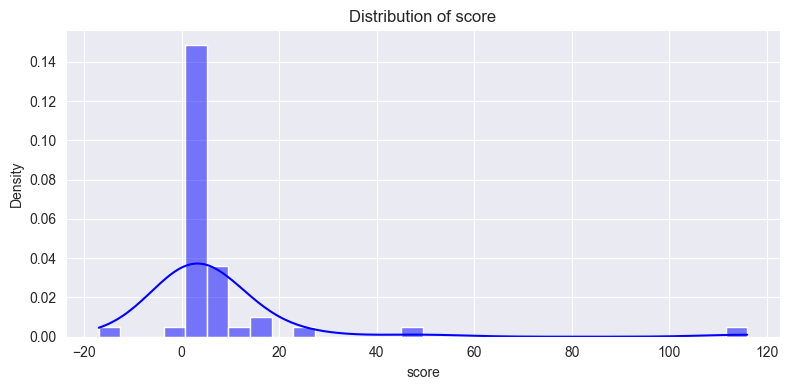

In [6]:
## Exploratory Data Analysis (EDA) – Score distribution
fig, axes = plot_numerical_distributions(
    comments_df,
    numerical_cols=["score"],
    save=True,
    fig_name="reddit_comments_score_distribution",
)

In [7]:
## Exploratory Data Analysis (EDA) – Token frequencies

"""
Here we perform a light-weight text cleaning using the existing TextCleaner
to inspect the most frequent tokens in the comments.

This is *not yet* the final modeling pipeline, but a quick EDA step.
"""

cleaner_eda = TextCleaner(
    lowercase=True,
    remove_urls=True,
    remove_punctuation=True,
    remove_digits=True,
    remove_stopwords=True,
    stopwords_lang="spanish",
    lemmatize=False,
    stem=False,
)

cleaned_body_array = cleaner_eda.fit_transform(comments_df[["body"]])
cleaned_body = pd.Series(cleaned_body_array.ravel())

# Concatenate all comments and split into tokens
all_tokens = " ".join(cleaned_body).split()
token_freq = pd.Series(all_tokens).value_counts().head(20)

logger.info("Top 20 most frequent tokens after basic cleaning:")
display(token_freq.to_frame("frequency"))

2025-11-29 21:13:16,413 | __main__ | INFO | Top 20 most frequent tokens after basic cleaning:


,frequency
si,16
movistar,12
baja,10
gb,9
sms,7
ahora,6
meses,5
mismo,5
cosas,5
mas,5


### Visual:

2025-11-29 21:13:16,606 | src.eda | INFO | Plot saved: reports/figures/reddit-comments-nlp\reddit_comments_top_tokens.png
2025-11-29 21:13:16,607 | src.data_loader | INFO | Completed: wrapper


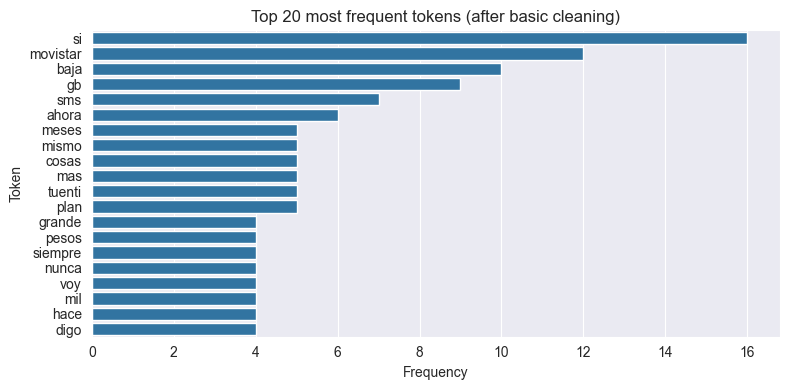

In [8]:
fig, ax = plot_top_frequencies(
    token_freq,
    top_n=20,
    title="Top 20 most frequent tokens (after basic cleaning)",
    xlabel="Frequency",
    ylabel="Token",
    horizontal=True,
    save=True,
    fig_name="reddit_comments_top_tokens",
)

## Text Feature Pipeline Design

Before jumping into model training, we design an **NLP feature pipeline** that is:

- **Consistent with the project architecture** (scikit-learn compatible, serializable).
- **Simple and interpretable**, avoiding premature complexity.
- **Easy to extend** (e.g., replacing TF-IDF with transformer-based embeddings in the future).

The proposed text feature pipeline is:

1. **TextCleaner (`src/preprocess.py`)**  
   - Lowercasing.
   - URL removal.
   - Punctuation and digit cleanup.
   - Optional removal of Spanish stopwords.

2. **Flattening step**  
   - `TextCleaner` returns a 2D array (`n_samples x 1`).  
   - We flatten it into a 1D array of strings to feed into a vectorizer.

3. **TF-IDF Vectorizer**  
   - `TfidfVectorizer` with:
     - Unigrams and bigrams (`ngram_range=(1, 2)`).
     - A capped vocabulary size (e.g. 5,000 features) to remain lightweight.

4. **Dimensionality reduction** (optional but recommended for dense models)  
   - `TruncatedSVD` to compress TF-IDF into a lower-dimensional dense representation (e.g. 50 components).

This pipeline will produce a **fixed-length numeric representation** of any new comment, which we can then feed into a classifier (e.g. Logistic Regression) to estimate a **text-based churn risk score**.

The actual training and evaluation of this text model will be performed in **Notebook 07**.

In [9]:
## Text feature pipeline (not trained yet)

text_features_pipeline = Pipeline(
    steps=[
        (
            "clean",
            TextCleaner(
                lowercase=True,
                remove_urls=True,
                remove_punctuation=True,
                remove_digits=True,
                remove_stopwords=True,
                stopwords_lang="spanish",
                lemmatize=False,
                stem=False,
            ),
        ),
        ("flatten", FunctionTransformer(lambda X: X.ravel(), validate=False)),
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
            ),
        ),
        (
            "svd",
            TruncatedSVD(
                n_components=50,
                random_state=42,
            ),
        ),
    ]
)

## Full churn-intent text model skeleton (to be trained in Notebook 07)

churn_text_model = Pipeline(
    steps=[
        ("features", text_features_pipeline),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logger.info("Text feature pipeline and churn_text_model skeleton defined.")

2025-11-29 21:13:16,791 | __main__ | INFO | Text feature pipeline and churn_text_model skeleton defined.


In [10]:
### Save the labeled comments dataset

file_path = "data/processed/reddit_comments_labeled.csv"
_ = save_df(
    comments_df,
    filename=file_path,
    fmt="csv",
    index=False,
)

2025-11-29 21:13:16,816 | src.data_loader | INFO | DataFrame saved: data/processed/reddit_comments_labeled.csv.csv | Shape: (44, 8)
2025-11-29 21:13:16,818 | src.data_loader | INFO | Completed: save_df


<br>

## Closing section – Results and Next Steps

#### Results and Insights from Notebook 06

In this notebook we:

1. Loaded and cleaned a small but realistic dataset of **Reddit comments about telco services**.
2. Defined a **churn-intent label** (`churn_signal`) using transparent, business-friendly text rules in Spanish.
3. Performed a light **EDA** on the comments:
   - Score distribution.
   - Most frequent tokens after basic cleaning.
   - Manual inspection of churn vs non-churn examples.
4. Designed a **scikit-learn compatible text feature pipeline**:
   - `TextCleaner` → normalized and cleaned comments.
   - `TfidfVectorizer` (unigrams + bigrams) → sparse text representation.
   - `TruncatedSVD` → compact dense features suitable for downstream models.
5. Defined the skeleton of a **churn-intent classifier from text** (`churn_text_model`), to be trained in the next notebook.

### How This Connects to the Telco Churn Pipeline

The text model built on Reddit comments is not a direct one-to-one match with the Telco Customer Churn dataset.  
However, it provides a blueprint for how **unstructured feedback** can be turned into:

- A **numeric text score** (e.g. `nlp_churn_score`) per comment or interaction.
- Complementary signals that can be aggregated at customer level and fed into the **structured churn model**.

In practice, a telco could:

- Score each new support ticket or social media comment with `churn_text_model`.
- Aggregate these scores over time per customer.
- Add the aggregated score(s) as an additional feature to the Telco churn pipeline we developed in previous notebooks.

---

### Next Steps – Notebook 07

In the next notebook we will:

1. Train and evaluate `churn_text_model` on the labeled Reddit comments:
   - Use cross-validation to assess how well text alone can detect churn intent.
   - Analyze model coefficients and key n-grams.
2. Extract a **text-based churn risk score**:
   - Use `predict_proba` to obtain `nlp_churn_score` per comment.
3. Discuss and illustrate how `nlp_churn_score` could be:
   - Integrated with the **Telco churn feature space**.
   - Used as a standalone **text alert system** for at-risk customers.

This will close the experimentation phase with a **hybrid, business-oriented view**:  
structured signals (contracts, billing) + unstructured signals (text feedback).

---

### Author

<a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/">**Flavio Aguirre**</a><br>
<a href="https://coursera.org/share/e27ae5af81b56f99a2aa85289b7cdd04">***Data Scientist***</a>